/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

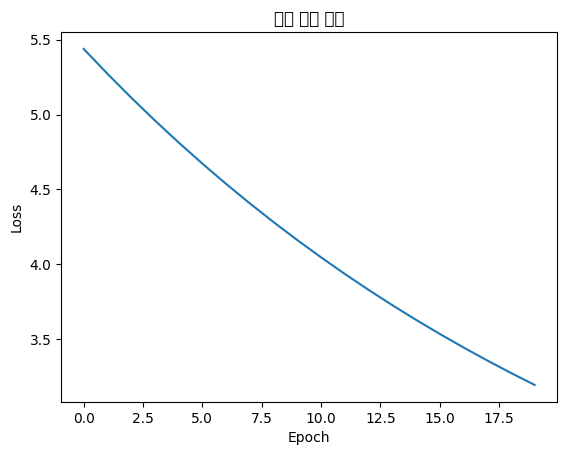

In [4]:
#라이브러리 임포트
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim


#데이터셋 정의
x_data = [[1,2],[3,4],[5,5],[7,8]]
y_data = [[1],[2],[3],[4]]

x_tensor = torch.tensor(x_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
#모델정의 (레이어 + 활성화 함수 + 순전파 )
class MyNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(2,4),
        nn.ReLU(),
        nn.Linear(4,1)
    )

  def forward(self, x):
    return self.layers(x)
#모델, 손실함수 및 옵티마이저 정의
model = MyNN()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
#학습 루프

num_epochs = 20
losses = []

for i in range(num_epochs):
  #가중치 초기화
  optimizer.zero_grad()
  #예측값 구하기
  y_pred = model(x_tensor)
  #손실 계산
  loss = loss_fn(y_pred, y_tensor)
  #역전파
  loss.backward()
  #가중치 업데이트
  optimizer.step()
  #손실값 저장
  losses.append(loss.item())
#결과 시각화
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('학습 손실 변화')
plt.show()